In [3]:
# Cell 1: Install the libraries required for the LangGraph + Groq agent

!pip install -q -U langgraph langchain-groq groq

print("Required packages installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 4.6 MB/s eta 0:00:00
Required packages installed successfully.


In [4]:
# Cell 2: Import the libraries required for the LangGraph agent

import os
import json
from typing import TypedDict, List

from google.colab import userdata
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
# Cell 3: Load the Groq API key securely from Google Colab Secrets

os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")

print("Groq API key loaded successfully.")

Groq API key loaded successfully.


In [6]:
# Cell 4: Initialize the Groq language model for the LangGraph agent

llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0,
)

print("Groq language model initialized successfully.")

Groq language model initialized successfully.


In [7]:
# Cell 5: Test the Groq model through the LangChain interface

response = llm.invoke(
    "Explain in one sentence what an agentic AI system is."
)

print(response.content)

An agentic AI system is an autonomous artificial intelligence that can set its own goals, make decisions, and take actions to achieve those goals without direct human intervention.


In [8]:
# Cell 6: Define the state that will flow through our LangGraph agent

class AgentState(TypedDict):
    user_instruction: str
    plan: List[str]
    current_step: int
    execution_results: List[str]
    verification: str
    needs_replan: bool


print("Agent state defined successfully.")

Agent state defined successfully.


In [9]:
# Cell 7: Define the robot skills that the agent can use to perform a task

def reach_object(object_name: str) -> str:
    """Move the robot toward the specified object."""
    return f"Robot reached the {object_name}."


def grasp_object(object_name: str) -> str:
    """Grasp the specified object."""
    return f"Robot grasped the {object_name}."


def transport_object(object_name: str, destination: str) -> str:
    """Move a grasped object to a destination."""
    return f"Robot transported the {object_name} to the {destination}."


def place_object(object_name: str, destination: str) -> str:
    """Place the object at the destination."""
    return f"Robot placed the {object_name} in the {destination}."


def retreat() -> str:
    """Move the robot away after completing the manipulation."""
    return "Robot safely retreated."


print("Robot skills defined successfully.")

Robot skills defined successfully.


In [10]:
# Cell 8: Create the planning node that converts a human instruction into robot subtasks

def planner_node(state: AgentState) -> AgentState:
    instruction = state["user_instruction"]

    prompt = f"""
You are a robot task planner.

Convert the following human instruction into a sequence of simple robot subtasks.

Human instruction:
{instruction}

Available subtasks:
- REACH
- GRASP
- TRANSPORT
- PLACE
- RETREAT

Return ONLY a JSON list of subtasks.
Do not include explanations.

Example:
["REACH", "GRASP", "TRANSPORT", "PLACE", "RETREAT"]
"""

    response = llm.invoke(prompt)

    try:
        plan = json.loads(response.content)
    except json.JSONDecodeError:
        plan = []

    return {
        **state,
        "plan": plan,
        "current_step": 0,
        "execution_results": [],
        "verification": "NOT_STARTED",
        "needs_replan": False,
    }


print("Planner node created successfully.")

Planner node created successfully.


In [11]:
# Cell 9: Test the planner with a real robot manipulation instruction

initial_state: AgentState = {
    "user_instruction": "Pick up the red object and place it inside the box.",
    "plan": [],
    "current_step": 0,
    "execution_results": [],
    "verification": "NOT_STARTED",
    "needs_replan": False,
}

planned_state = planner_node(initial_state)

print("Human instruction:")
print(planned_state["user_instruction"])

print("\nGenerated robot plan:")
for step_number, step in enumerate(planned_state["plan"], start=1):
    print(f"{step_number}. {step}")

Human instruction:
Pick up the red object and place it inside the box.

Generated robot plan:
1. REACH
2. GRASP
3. TRANSPORT
4. PLACE
5. RETREAT


In [12]:
# Cell 10: Create the execution node that maps planned subtasks to robot skills

def execution_node(state: AgentState) -> AgentState:
    plan = state["plan"]
    results = []

    for step in plan:
        if step == "REACH":
            result = reach_object("red object")

        elif step == "GRASP":
            result = grasp_object("red object")

        elif step == "TRANSPORT":
            result = transport_object("red object", "box")

        elif step == "PLACE":
            result = place_object("red object", "box")

        elif step == "RETREAT":
            result = retreat()

        else:
            result = f"Unknown robot skill: {step}"

        results.append(result)

    return {
        **state,
        "execution_results": results,
        "current_step": len(plan),
    }


print("Execution node created successfully.")

Execution node created successfully.


In [13]:
# Cell 11: Execute the plan generated by the Groq planner

executed_state = execution_node(planned_state)

print("Execution results:\n")

for step_number, result in enumerate(
    executed_state["execution_results"], start=1
):
    print(f"{step_number}. {result}")

print("\nCurrent step:", executed_state["current_step"])

Execution results:

1. Robot reached the red object.
2. Robot grasped the red object.
3. Robot transported the red object to the box.
4. Robot placed the red object in the box.
5. Robot safely retreated.

Current step: 5


In [14]:
# Cell 12: Create the verification node that checks whether the robot completed the task

def verification_node(state: AgentState) -> AgentState:
    execution_results = state["execution_results"]

    if not execution_results:
        verification = "FAILED"
    elif "Robot placed the red object in the box." in execution_results:
        verification = "SUCCESS"
    else:
        verification = "FAILED"

    return {
        **state,
        "verification": verification,
        "needs_replan": verification == "FAILED",
    }


print("Verification node created successfully.")

Verification node created successfully.


In [15]:
# Cell 13: Build the LangGraph workflow connecting planning, execution, and verification

workflow = StateGraph(AgentState)

# Add the agent nodes
workflow.add_node("planner", planner_node)
workflow.add_node("executor", execution_node)
workflow.add_node("verifier", verification_node)

# Connect the nodes
workflow.add_edge(START, "planner")
workflow.add_edge("planner", "executor")
workflow.add_edge("executor", "verifier")
workflow.add_edge("verifier", END)

# Compile the graph
agent = workflow.compile()

print("LangGraph agent compiled successfully.")

LangGraph agent compiled successfully.


In [16]:
# Cell 14: Create the replanning node that generates a new plan after failure

def replanner_node(state: AgentState) -> AgentState:
    instruction = state["user_instruction"]
    previous_plan = state["plan"]
    verification = state["verification"]

    prompt = f"""
You are a robot recovery planner.

The robot was given this task:
{instruction}

Previous plan:
{previous_plan}

Verification result:
{verification}

Create a new plan that attempts the task again.

Available subtasks:
- REACH
- GRASP
- TRANSPORT
- PLACE
- RETREAT

Return ONLY a JSON list of subtasks.
Do not include explanations.
"""

    response = llm.invoke(prompt)

    try:
        new_plan = json.loads(response.content)
    except json.JSONDecodeError:
        new_plan = previous_plan

    return {
        **state,
        "plan": new_plan,
        "current_step": 0,
        "execution_results": [],
        "verification": "NOT_STARTED",
        "needs_replan": False,
    }


print("Replanning node created successfully.")

Replanning node created successfully.


In [17]:
# Cell 15: Route the workflow to either completion or recovery based on verification

def verification_router(state: AgentState) -> str:
    if state["needs_replan"]:
        return "replan"

    return "end"


print("Verification router created successfully.")

Verification router created successfully.


In [18]:
# Cell 16: Build the complete LangGraph with conditional recovery and replanning

workflow = StateGraph(AgentState)

# Add nodes
workflow.add_node("planner", planner_node)
workflow.add_node("executor", execution_node)
workflow.add_node("verifier", verification_node)
workflow.add_node("replanner", replanner_node)

# Connect the main workflow
workflow.add_edge(START, "planner")
workflow.add_edge("planner", "executor")
workflow.add_edge("executor", "verifier")

# Route based on verification result
workflow.add_conditional_edges(
    "verifier",
    verification_router,
    {
        "replan": "replanner",
        "end": END,
    },
)

# After replanning, execute the new plan
workflow.add_edge("replanner", "executor")

# Compile the complete agent
agent = workflow.compile()

print("Complete LangGraph agent compiled successfully.")

Complete LangGraph agent compiled successfully.


In [19]:
# Cell 17: Run the complete LangGraph agent from instruction to verification

final_state = agent.invoke({
    "user_instruction": "Pick up the red object and place it inside the box.",
    "plan": [],
    "current_step": 0,
    "execution_results": [],
    "verification": "NOT_STARTED",
    "needs_replan": False,
})

print("===== AGENT EXECUTION =====")

print("\nUser instruction:")
print(final_state["user_instruction"])

print("\nFinal plan:")
for step_number, step in enumerate(final_state["plan"], start=1):
    print(f"{step_number}. {step}")

print("\nExecution results:")
for step_number, result in enumerate(
    final_state["execution_results"], start=1
):
    print(f"{step_number}. {result}")

print("\nVerification:")
print(final_state["verification"])

print("\nNeeds replanning:")
print(final_state["needs_replan"])

===== AGENT EXECUTION =====

User instruction:
Pick up the red object and place it inside the box.

Final plan:
1. REACH
2. GRASP
3. TRANSPORT
4. PLACE
5. RETREAT

Execution results:
1. Robot reached the red object.
2. Robot grasped the red object.
3. Robot transported the red object to the box.
4. Robot placed the red object in the box.
5. Robot safely retreated.

Verification:
SUCCESS

Needs replanning:
False


In [20]:
# Cell 18: Simulate a temporary robot failure so the agent can demonstrate recovery

placement_attempts = 0


def place_object_with_failure(object_name: str, destination: str) -> str:
    global placement_attempts

    placement_attempts += 1

    if placement_attempts == 1:
        return (
            f"Robot failed to place the {object_name} in the {destination}. "
            "The object was not detected inside the destination."
        )

    return f"Robot placed the {object_name} in the {destination}."


print("Failure simulation enabled.")

Failure simulation enabled.


In [21]:
# Cell 19: Update the executor so the PLACE skill can fail and trigger recovery

def execution_node_with_failure(state: AgentState) -> AgentState:
    plan = state["plan"]
    results = []

    for step in plan:
        if step == "REACH":
            result = reach_object("red object")

        elif step == "GRASP":
            result = grasp_object("red object")

        elif step == "TRANSPORT":
            result = transport_object("red object", "box")

        elif step == "PLACE":
            result = place_object_with_failure("red object", "box")

        elif step == "RETREAT":
            result = retreat()

        else:
            result = f"Unknown robot skill: {step}"

        results.append(result)

        # Stop execution immediately if a skill fails
        if "failed" in result.lower():
            break

    return {
        **state,
        "execution_results": results,
        "current_step": len(results),
    }


print("Failure-aware execution node created successfully.")

Failure-aware execution node created successfully.


In [22]:
# Cell 20: Rebuild the LangGraph using the failure-aware execution node

workflow = StateGraph(AgentState)

# Add nodes
workflow.add_node("planner", planner_node)
workflow.add_node("executor", execution_node_with_failure)
workflow.add_node("verifier", verification_node)
workflow.add_node("replanner", replanner_node)

# Main workflow
workflow.add_edge(START, "planner")
workflow.add_edge("planner", "executor")
workflow.add_edge("executor", "verifier")

# Conditional recovery
workflow.add_conditional_edges(
    "verifier",
    verification_router,
    {
        "replan": "replanner",
        "end": END,
    },
)

# Replanner sends the new plan back to execution
workflow.add_edge("replanner", "executor")

# Compile the recovery-enabled graph
agent = workflow.compile()

print("Recovery-enabled LangGraph agent compiled successfully.")

Recovery-enabled LangGraph agent compiled successfully.


In [23]:
# Cell 21: Run the recovery-enabled agent and observe failure, replanning, and retry

# Reset the simulated failure counter
placement_attempts = 0

initial_state: AgentState = {
    "user_instruction": "Pick up the red object and place it inside the box.",
    "plan": [],
    "current_step": 0,
    "execution_results": [],
    "verification": "NOT_STARTED",
    "needs_replan": False,
}

final_state = agent.invoke(initial_state)

print("===== RECOVERY TEST =====")

print("\nFinal plan:")
for step_number, step in enumerate(final_state["plan"], start=1):
    print(f"{step_number}. {step}")

print("\nFinal execution results:")
for step_number, result in enumerate(
    final_state["execution_results"], start=1
):
    print(f"{step_number}. {result}")

print("\nFinal verification:")
print(final_state["verification"])

print("\nNeeds replanning:")
print(final_state["needs_replan"])

print("\nPlacement attempts:")
print(placement_attempts)

===== RECOVERY TEST =====

Final plan:
1. REACH
2. GRASP
3. RETREAT
4. TRANSPORT
5. PLACE
6. RETREAT

Final execution results:
1. Robot reached the red object.
2. Robot grasped the red object.
3. Robot safely retreated.
4. Robot transported the red object to the box.
5. Robot placed the red object in the box.
6. Robot safely retreated.

Final verification:
SUCCESS

Needs replanning:
False

Placement attempts:
2


In [24]:
# Cell 22: Define the simulated robot state used to validate skill execution

class RobotState(TypedDict):
    object_detected: bool
    robot_at_object: bool
    object_grasped: bool
    robot_at_destination: bool
    object_placed: bool
    task_completed: bool


robot_state: RobotState = {
    "object_detected": True,
    "robot_at_object": False,
    "object_grasped": False,
    "robot_at_destination": False,
    "object_placed": False,
    "task_completed": False,
}

print("Robot state initialized successfully.")

Robot state initialized successfully.


In [25]:
# Cell 23: Define preconditions that determine whether each robot skill can execute

SKILL_PRECONDITIONS = {
    "REACH": lambda s: s["object_detected"],
    "GRASP": lambda s: s["robot_at_object"],
    "TRANSPORT": lambda s: s["object_grasped"],
    "PLACE": lambda s: (
        s["object_grasped"] and s["robot_at_destination"]
    ),
    "RETREAT": lambda s: s["object_placed"],
}

print("Robot skill preconditions defined successfully.")

Robot skill preconditions defined successfully.


In [26]:
# Cell 24: Define how each robot skill changes the robot state

def apply_skill(step: str, state: RobotState) -> str:
    """Validate and apply a robot skill to the current state."""

    if step not in SKILL_PRECONDITIONS:
        return f"Unknown skill: {step}"

    if not SKILL_PRECONDITIONS[step](state):
        return f"PRECONDITION_FAILED: {step}"

    if step == "REACH":
        state["robot_at_object"] = True
        return "Robot reached the red object."

    if step == "GRASP":
        state["object_grasped"] = True
        return "Robot grasped the red object."

    if step == "TRANSPORT":
        state["robot_at_destination"] = True
        return "Robot transported the red object to the box."

    if step == "PLACE":
        state["object_placed"] = True
        state["object_grasped"] = False
        return "Robot placed the red object in the box."

    if step == "RETREAT":
        state["task_completed"] = True
        return "Robot safely retreated."

    return "Skill execution completed."


print("State transition system created successfully.")

State transition system created successfully.


In [27]:
# Cell 25: Execute the agent's plan while validating skill preconditions and updating robot state

def state_aware_executor(state: AgentState) -> AgentState:
    plan = state["plan"]
    results = []

    # Start every execution with a fresh robot state.
    current_robot_state: RobotState = {
        "object_detected": True,
        "robot_at_object": False,
        "object_grasped": False,
        "robot_at_destination": False,
        "object_placed": False,
        "task_completed": False,
    }

    for step in plan:
        result = apply_skill(step, current_robot_state)
        results.append(result)

        # Stop immediately if a skill's precondition fails.
        if result.startswith("PRECONDITION_FAILED"):
            break

    return {
        **state,
        "execution_results": results,
        "current_step": len(results),
    }


print("State-aware executor created successfully.")

State-aware executor created successfully.


In [28]:
# Cell 26: Test the state-aware executor with a physically valid robot plan

test_state: AgentState = {
    "user_instruction": "Pick up the red object and place it inside the box.",
    "plan": [
        "REACH",
        "GRASP",
        "TRANSPORT",
        "PLACE",
        "RETREAT",
    ],
    "current_step": 0,
    "execution_results": [],
    "verification": "NOT_STARTED",
    "needs_replan": False,
}

test_result = state_aware_executor(test_state)

print("===== STATE-AWARE EXECUTION =====")

for step_number, result in enumerate(
    test_result["execution_results"], start=1
):
    print(f"{step_number}. {result}")

print("\nSteps executed:", test_result["current_step"])

===== STATE-AWARE EXECUTION =====
1. Robot reached the red object.
2. Robot grasped the red object.
3. Robot transported the red object to the box.
4. Robot placed the red object in the box.
5. Robot safely retreated.

Steps executed: 5


In [29]:
# Cell 27: Test whether the executor rejects a physically invalid action sequence

invalid_test_state: AgentState = {
    "user_instruction": "Pick up the red object and place it inside the box.",
    "plan": [
        "REACH",
        "GRASP",
        "RETREAT",
        "TRANSPORT",
        "PLACE",
    ],
    "current_step": 0,
    "execution_results": [],
    "verification": "NOT_STARTED",
    "needs_replan": False,
}

invalid_result = state_aware_executor(invalid_test_state)

print("===== INVALID PLAN TEST =====")

for step_number, result in enumerate(
    invalid_result["execution_results"], start=1
):
    print(f"{step_number}. {result}")

print("\nSteps executed:", invalid_result["current_step"])

===== INVALID PLAN TEST =====
1. Robot reached the red object.
2. Robot grasped the red object.
3. PRECONDITION_FAILED: RETREAT

Steps executed: 3


In [30]:
# Cell 28: Update the executor so precondition failures trigger replanning

def state_aware_executor(state: AgentState) -> AgentState:
    plan = state["plan"]
    results = []

    current_robot_state: RobotState = {
        "object_detected": True,
        "robot_at_object": False,
        "object_grasped": False,
        "robot_at_destination": False,
        "object_placed": False,
        "task_completed": False,
    }

    execution_failed = False

    for step in plan:
        result = apply_skill(step, current_robot_state)
        results.append(result)

        if result.startswith("PRECONDITION_FAILED"):
            execution_failed = True
            break

    return {
        **state,
        "execution_results": results,
        "current_step": len(results),
        "verification": "FAILED" if execution_failed else state["verification"],
        "needs_replan": execution_failed,
    }


print("State-aware recovery executor created successfully.")

State-aware recovery executor created successfully.


In [31]:
# Cell 29: Verify that a precondition failure activates the replanning signal

recovery_test_state: AgentState = {
    "user_instruction": "Pick up the red object and place it inside the box.",
    "plan": [
        "REACH",
        "GRASP",
        "RETREAT",
        "TRANSPORT",
        "PLACE",
    ],
    "current_step": 0,
    "execution_results": [],
    "verification": "NOT_STARTED",
    "needs_replan": False,
}

recovery_result = state_aware_executor(recovery_test_state)

print("===== RECOVERY SIGNAL TEST =====")

for step_number, result in enumerate(
    recovery_result["execution_results"], start=1
):
    print(f"{step_number}. {result}")

print("\nVerification:", recovery_result["verification"])
print("Needs replanning:", recovery_result["needs_replan"])

===== RECOVERY SIGNAL TEST =====
1. Robot reached the red object.
2. Robot grasped the red object.
3. PRECONDITION_FAILED: RETREAT

Verification: FAILED
Needs replanning: True


In [32]:
# Cell 30: Update the replanner so it receives the execution failure and generates a corrected plan

def state_aware_replanner_node(state: AgentState) -> AgentState:
    instruction = state["user_instruction"]
    previous_plan = state["plan"]
    execution_results = state["execution_results"]

    prompt = f"""
You are a robot recovery planner.

Task:
{instruction}

Previous plan:
{previous_plan}

Execution results:
{execution_results}

The previous plan failed because one of its actions violated
the robot's state preconditions.

Generate a corrected plan.

IMPORTANT:
- REACH must happen before GRASP.
- GRASP must happen before TRANSPORT.
- TRANSPORT must happen before PLACE.
- PLACE must happen before RETREAT.
- Do not insert RETREAT before PLACE.
- Use only these subtasks:
  REACH, GRASP, TRANSPORT, PLACE, RETREAT

Return ONLY a JSON list.
Do not include explanations.

Example:
["REACH", "GRASP", "TRANSPORT", "PLACE", "RETREAT"]
"""

    response = llm.invoke(prompt)

    try:
        new_plan = json.loads(response.content)
    except json.JSONDecodeError:
        new_plan = [
            "REACH",
            "GRASP",
            "TRANSPORT",
            "PLACE",
            "RETREAT",
        ]

    return {
        **state,
        "plan": new_plan,
        "current_step": 0,
        "execution_results": [],
        "verification": "NOT_STARTED",
        "needs_replan": False,
    }


print("State-aware replanner created successfully.")

State-aware replanner created successfully.


In [33]:
# Cell 31: Test whether the recovery planner can correct an invalid robot plan

failed_state: AgentState = {
    "user_instruction": "Pick up the red object and place it inside the box.",
    "plan": [
        "REACH",
        "GRASP",
        "RETREAT",
        "TRANSPORT",
        "PLACE",
    ],
    "current_step": 3,
    "execution_results": [
        "Robot reached the red object.",
        "Robot grasped the red object.",
        "PRECONDITION_FAILED: RETREAT",
    ],
    "verification": "FAILED",
    "needs_replan": True,
}

replanned_state = state_aware_replanner_node(failed_state)

print("===== REPLANNING TEST =====")

print("\nPrevious plan:")
print(failed_state["plan"])

print("\nCorrected plan:")
for step_number, step in enumerate(
    replanned_state["plan"], start=1
):
    print(f"{step_number}. {step}")

===== REPLANNING TEST =====

Previous plan:
['REACH', 'GRASP', 'RETREAT', 'TRANSPORT', 'PLACE']

Corrected plan:
1. REACH
2. GRASP
3. TRANSPORT
4. PLACE
5. RETREAT


In [34]:
# Cell 32: Build the complete LangGraph using state-aware execution and recovery

workflow = StateGraph(AgentState)

# Add the agent nodes.
workflow.add_node("planner", planner_node)
workflow.add_node("executor", state_aware_executor)
workflow.add_node("verifier", verification_node)
workflow.add_node("replanner", state_aware_replanner_node)

# Normal execution path.
workflow.add_edge(START, "planner")
workflow.add_edge("planner", "executor")
workflow.add_edge("executor", "verifier")

# Decide whether the task succeeded or needs recovery.
workflow.add_conditional_edges(
    "verifier",
    verification_router,
    {
        "replan": "replanner",
        "end": END,
    },
)

# After replanning, execute the corrected plan.
workflow.add_edge("replanner", "executor")

agent = workflow.compile()

print("State-aware recovery LangGraph compiled successfully.")

State-aware recovery LangGraph compiled successfully.


In [35]:
# Cell 33: Run the complete agent from human instruction through planning, execution, and verification

initial_state: AgentState = {
    "user_instruction": "Pick up the red object and place it inside the box.",
    "plan": [],
    "current_step": 0,
    "execution_results": [],
    "verification": "NOT_STARTED",
    "needs_replan": False,
}

final_state = agent.invoke(initial_state)

print("===== COMPLETE AGENT RUN =====")

print("\nFinal plan:")
for step_number, step in enumerate(
    final_state["plan"], start=1
):
    print(f"{step_number}. {step}")

print("\nExecution results:")
for step_number, result in enumerate(
    final_state["execution_results"], start=1
):
    print(f"{step_number}. {result}")

print("\nVerification:", final_state["verification"])
print("Needs replanning:", final_state["needs_replan"])

===== COMPLETE AGENT RUN =====

Final plan:
1. REACH
2. GRASP
3. TRANSPORT
4. PLACE
5. RETREAT

Execution results:
1. Robot reached the red object.
2. Robot grasped the red object.
3. Robot transported the red object to the box.
4. Robot placed the red object in the box.
5. Robot safely retreated.

Verification: SUCCESS
Needs replanning: False


In [36]:
# Cell 34: Create a deliberately faulty planner to test LangGraph recovery

def faulty_planner_node(state: AgentState) -> AgentState:
    """Generate an intentionally invalid plan for recovery testing."""

    bad_plan = [
        "REACH",
        "GRASP",
        "RETREAT",
        "TRANSPORT",
        "PLACE",
    ]

    return {
        **state,
        "plan": bad_plan,
        "current_step": 0,
        "execution_results": [],
        "verification": "NOT_STARTED",
        "needs_replan": False,
    }


print("Faulty planner created for recovery testing.")

Faulty planner created for recovery testing.


In [37]:
# Cell 35: Build a LangGraph that starts with the faulty planner and recovers automatically

recovery_workflow = StateGraph(AgentState)

recovery_workflow.add_node("planner", faulty_planner_node)
recovery_workflow.add_node("executor", state_aware_executor)
recovery_workflow.add_node("verifier", verification_node)
recovery_workflow.add_node("replanner", state_aware_replanner_node)

recovery_workflow.add_edge(START, "planner")
recovery_workflow.add_edge("planner", "executor")
recovery_workflow.add_edge("executor", "verifier")

recovery_workflow.add_conditional_edges(
    "verifier",
    verification_router,
    {
        "replan": "replanner",
        "end": END,
    },
)

recovery_workflow.add_edge("replanner", "executor")

recovery_agent = recovery_workflow.compile()

print("Recovery-test LangGraph compiled successfully.")

Recovery-test LangGraph compiled successfully.


In [38]:
# Cell 36: Run the agent through failure, replanning, retry, and final verification

recovery_initial_state: AgentState = {
    "user_instruction": "Pick up the red object and place it inside the box.",
    "plan": [],
    "current_step": 0,
    "execution_results": [],
    "verification": "NOT_STARTED",
    "needs_replan": False,
}

recovery_final_state = recovery_agent.invoke(
    recovery_initial_state
)

print("===== FULL RECOVERY RUN =====")

print("\nFinal plan:")
for step_number, step in enumerate(
    recovery_final_state["plan"], start=1
):
    print(f"{step_number}. {step}")

print("\nFinal execution results:")
for step_number, result in enumerate(
    recovery_final_state["execution_results"], start=1
):
    print(f"{step_number}. {result}")

print("\nFinal verification:")
print(recovery_final_state["verification"])

print("\nNeeds replanning:")
print(recovery_final_state["needs_replan"])

===== FULL RECOVERY RUN =====

Final plan:
1. REACH
2. GRASP
3. TRANSPORT
4. PLACE
5. RETREAT

Final execution results:
1. Robot reached the red object.
2. Robot grasped the red object.
3. Robot transported the red object to the box.
4. Robot placed the red object in the box.
5. Robot safely retreated.

Final verification:
SUCCESS

Needs replanning:
False


In [39]:
# Cell 37: Extend the agent state with information obtained from visual perception

class PerceptionState(TypedDict):
    user_instruction: str
    scene_description: str
    detected_objects: List[str]
    plan: List[str]
    current_step: int
    execution_results: List[str]
    verification: str
    needs_replan: bool

print("Perception-aware agent state defined successfully.")

Perception-aware agent state defined successfully.


In [40]:
# Cell 38: Create the perception node that converts a scene description into detected objects

def perception_node(state: PerceptionState) -> PerceptionState:
    scene = state["scene_description"]

    # In the next phase, this information will come from a VLM.
    # For now, we extract the objects using the LLM.
    prompt = f"""
You are a robot perception system.

Analyze this scene description:

{scene}

Identify the relevant objects that a robot could interact with.

Return ONLY a JSON list of object names.
Do not include explanations.

Example:
["red object", "box"]
"""

    response = llm.invoke(prompt)

    try:
        detected_objects = json.loads(response.content)
    except json.JSONDecodeError:
        detected_objects = []

    return {
        **state,
        "detected_objects": detected_objects,
    }


print("Perception node created successfully.")

Perception node created successfully.


In [41]:
# Cell 39: Test the perception node with a simple robot workspace description

perception_test_state: PerceptionState = {
    "user_instruction": "Pick up the red object and place it inside the box.",
    "scene_description": (
        "The robot workspace contains one small red object "
        "on the table and a blue box next to it."
    ),
    "detected_objects": [],
    "plan": [],
    "current_step": 0,
    "execution_results": [],
    "verification": "NOT_STARTED",
    "needs_replan": False,
}

perceived_state = perception_node(perception_test_state)

print("===== PERCEPTION TEST =====")

print("\nScene:")
print(perceived_state["scene_description"])

print("\nDetected objects:")
for obj in perceived_state["detected_objects"]:
    print("-", obj)

===== PERCEPTION TEST =====

Scene:
The robot workspace contains one small red object on the table and a blue box next to it.

Detected objects:
- red object
- box


In [42]:
# Cell 40: Initialize the Groq vision-language model for visual perception

from groq import Groq

groq_client = Groq(
    api_key=os.environ["GROQ_API_KEY"]
)

VISION_MODEL = "qwen/qwen3.6-27b"

print("Groq vision-language model initialized successfully.")
print("Vision model:", VISION_MODEL)

Groq vision-language model initialized successfully.
Vision model: qwen/qwen3.6-27b


In [43]:
# Cell 41: Create a simple synthetic robot workspace image for VLM testing

from PIL import Image, ImageDraw

image = Image.new("RGB", (640, 480), "white")
draw = ImageDraw.Draw(image)

# Draw a simple table/workspace.
draw.rectangle(
    [40, 40, 600, 440],
    outline="black",
    width=3
)

# Draw the red object.
draw.rectangle(
    [180, 180, 260, 260],
    fill="red"
)

# Draw the blue destination box.
draw.rectangle(
    [380, 150, 520, 300],
    fill="blue"
)

# Add labels to make the test scene visually clear.
draw.text(
    (185, 270),
    "red object",
    fill="black"
)

draw.text(
    (405, 310),
    "box",
    fill="black"
)

image_path = "/content/robot_workspace.png"
image.save(image_path)

print("Test workspace image created successfully.")
print("Image path:", image_path)

Test workspace image created successfully.
Image path: /content/robot_workspace.png


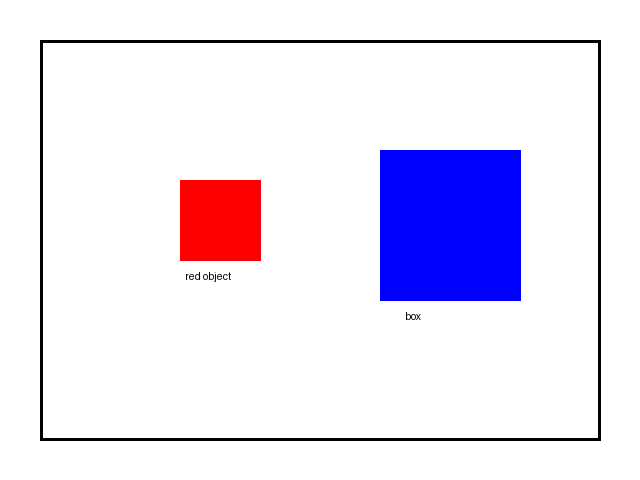

In [44]:
# Cell 42: Display the synthetic robot workspace for visual inspection

from IPython.display import display

display(image)

In [46]:
# Cell 43: Check which vision-capable models are actually available to the current Groq API key

available_models = groq_client.models.list()

print("===== AVAILABLE MULTIMODAL MODELS =====")

for model in available_models.data:
    model_id = model.id.lower()

    # Show likely vision/multimodal model families.
    if (
        "qwen" in model_id
        or "llama-4" in model_id
        or "vision" in model_id
    ):
        print(model.id)

===== AVAILABLE MULTIMODAL MODELS =====
qwen/qwen3.8-27b


In [47]:
# Cell 43: Set the vision model to the multimodal model available to our Groq API key

VISION_MODEL = "qwen/qwen3.8-27b"

print("Vision model updated successfully.")
print("Vision model:", VISION_MODEL)

Vision model updated successfully.
Vision model: qwen/qwen3.8-27b


In [48]:
# Cell 44: Send the actual workspace image to the Groq vision-language model

import base64

# Convert the image into a base64 data URL.
with open(image_path, "rb") as image_file:
    image_base64 = base64.b64encode(
        image_file.read()
    ).decode("utf-8")

image_data_url = f"data:image/png;base64,{image_base64}"

# Ask the VLM to identify and classify objects in the scene.
vision_response = groq_client.chat.completions.create(
    model=VISION_MODEL,
    temperature=0,
    max_completion_tokens=512,
    response_format={"type": "json_object"},
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": """
Analyze this robot workspace image.

The robot must perform this instruction:
"Pick up the red object and place it inside the box."

Identify the relevant objects and their roles.

Return ONLY JSON using this structure:

{
  "objects": [
    {
      "name": "object name",
      "color": "object color",
      "role": "target_object or destination or other"
    }
  ]
}
"""
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": image_data_url
                    }
                }
            ]
        }
    ]
)

vision_output = vision_response.choices[0].message.content

print("===== VLM PERCEPTION =====")
print(vision_output)

===== VLM PERCEPTION =====
{
  "objects": [
    {
      "name": "red object",
      "color": "red",
      "role": "target_object"
    },
    {
      "name": "box",
      "color": "blue",
      "role": "destination"
    }
  ]
}


In [49]:
# Cell 45: Convert the VLM's JSON response into structured perception state

parsed_vision = json.loads(vision_output)

detected_objects = parsed_vision["objects"]

print("===== STRUCTURED PERCEPTION =====")

for obj in detected_objects:
    print(
        f"Name: {obj['name']} | "
        f"Color: {obj['color']} | "
        f"Role: {obj['role']}"
    )

===== STRUCTURED PERCEPTION =====
Name: red object | Color: red | Role: target_object
Name: box | Color: blue | Role: destination


In [50]:
# Cell 46: Create a planner that uses both human intent and visual perception

def perception_grounded_planner(
    state: PerceptionState
) -> PerceptionState:

    instruction = state["user_instruction"]
    objects = state["detected_objects"]

    prompt = f"""
You are a robot task planner.

Human instruction:
{instruction}

Visual perception:
{json.dumps(objects, indent=2)}

Use the visual perception to identify the target object
and destination.

Available robot subtasks:
- REACH
- GRASP
- TRANSPORT
- PLACE
- RETREAT

Planning constraints:
- REACH must occur before GRASP.
- GRASP must occur before TRANSPORT.
- TRANSPORT must occur before PLACE.
- PLACE must occur before RETREAT.
- Use only the available subtasks.

Return ONLY a JSON list of subtasks.
Do not include explanations.

Example:
["REACH", "GRASP", "TRANSPORT", "PLACE", "RETREAT"]
"""

    response = llm.invoke(prompt)

    try:
        plan = json.loads(response.content)
    except json.JSONDecodeError:
        plan = []

    return {
        **state,
        "plan": plan,
        "current_step": 0,
        "execution_results": [],
        "verification": "NOT_STARTED",
        "needs_replan": False,
    }


print("Perception-grounded planner created successfully.")

Perception-grounded planner created successfully.


In [51]:
# Cell 47: Test the VLM-to-planner pipeline

perception_planning_state: PerceptionState = {
    "user_instruction": "Pick up the red object and place it inside the box.",
    "scene_description": "",
    "detected_objects": detected_objects,
    "plan": [],
    "current_step": 0,
    "execution_results": [],
    "verification": "NOT_STARTED",
    "needs_replan": False,
}

planned_from_perception = perception_grounded_planner(
    perception_planning_state
)

print("===== VLM → PLANNER =====")

print("\nDetected objects:")
for obj in planned_from_perception["detected_objects"]:
    print(
        f"- {obj['name']} "
        f"({obj['color']}, {obj['role']})"
    )

print("\nGenerated plan:")
for step_number, step in enumerate(
    planned_from_perception["plan"],
    start=1
):
    print(f"{step_number}. {step}")

===== VLM → PLANNER =====

Detected objects:
- red object (red, target_object)
- box (blue, destination)

Generated plan:
1. REACH
2. GRASP
3. TRANSPORT
4. PLACE
5. RETREAT


In [52]:
# Cell 48: Extract the target object and destination identified by the VLM

def extract_task_objects(objects: List[dict]):
    target_object = None
    destination = None

    for obj in objects:
        if obj["role"] == "target_object":
            target_object = obj["name"]

        elif obj["role"] == "destination":
            destination = obj["name"]

    return target_object, destination


target_object, destination = extract_task_objects(
    detected_objects
)

print("Target object:", target_object)
print("Destination:", destination)

Target object: red object
Destination: box


In [53]:
# Cell 49: Create robot skills that use objects identified by the VLM

def perception_aware_executor(
    state: PerceptionState
) -> PerceptionState:

    plan = state["plan"]
    objects = state["detected_objects"]

    target_object, destination = extract_task_objects(objects)

    results = []

    current_robot_state: RobotState = {
        "object_detected": target_object is not None,
        "robot_at_object": False,
        "object_grasped": False,
        "robot_at_destination": False,
        "object_placed": False,
        "task_completed": False,
    }

    for step in plan:

        if step not in SKILL_PRECONDITIONS:
            result = f"Unknown skill: {step}"

        elif not SKILL_PRECONDITIONS[step](current_robot_state):
            result = f"PRECONDITION_FAILED: {step}"

        elif step == "REACH":
            current_robot_state["robot_at_object"] = True
            result = f"Robot reached the {target_object}."

        elif step == "GRASP":
            current_robot_state["object_grasped"] = True
            result = f"Robot grasped the {target_object}."

        elif step == "TRANSPORT":
            current_robot_state["robot_at_destination"] = True
            result = (
                f"Robot transported the {target_object} "
                f"to the {destination}."
            )

        elif step == "PLACE":
            current_robot_state["object_placed"] = True
            current_robot_state["object_grasped"] = False
            result = (
                f"Robot placed the {target_object} "
                f"in the {destination}."
            )

        elif step == "RETREAT":
            current_robot_state["task_completed"] = True
            result = "Robot safely retreated."

        results.append(result)

        if result.startswith("PRECONDITION_FAILED"):
            break

    execution_failed = any(
        result.startswith("PRECONDITION_FAILED")
        for result in results
    )

    return {
        **state,
        "execution_results": results,
        "current_step": len(results),
        "verification": "FAILED" if execution_failed else state["verification"],
        "needs_replan": execution_failed,
    }


print("Perception-aware executor created successfully.")

Perception-aware executor created successfully.


In [54]:
# Cell 50: Run the perception-grounded plan through the perception-aware executor

execution_test_state: PerceptionState = {
    "user_instruction": "Pick up the red object and place it inside the box.",
    "scene_description": "",
    "detected_objects": detected_objects,
    "plan": planned_from_perception["plan"],
    "current_step": 0,
    "execution_results": [],
    "verification": "NOT_STARTED",
    "needs_replan": False,
}

execution_result = perception_aware_executor(
    execution_test_state
)

print("===== PERCEPTION → PLAN → EXECUTION =====")

print("\nPlan:")
for step_number, step in enumerate(
    execution_result["plan"],
    start=1
):
    print(f"{step_number}. {step}")

print("\nExecution:")
for step_number, result in enumerate(
    execution_result["execution_results"],
    start=1
):
    print(f"{step_number}. {result}")

print("\nNeeds replanning:")
print(execution_result["needs_replan"])

===== PERCEPTION → PLAN → EXECUTION =====

Plan:
1. REACH
2. GRASP
3. TRANSPORT
4. PLACE
5. RETREAT

Execution:
1. Robot reached the red object.
2. Robot grasped the red object.
3. Robot transported the red object to the box.
4. Robot placed the red object in the box.
5. Robot safely retreated.

Needs replanning:
False


In [55]:
# Cell 51: Define one unified state shared by perception, planning, execution, and recovery

class EmbodiedAgentState(TypedDict):
    user_instruction: str
    image_path: str
    detected_objects: List[dict]
    plan: List[str]
    current_step: int
    execution_results: List[str]
    verification: str
    needs_replan: bool


print("Unified embodied-agent state defined successfully.")

Unified embodied-agent state defined successfully.


In [56]:
# Cell 52: Create the unified VLM perception node for the embodied agent

def unified_perception_node(
    state: EmbodiedAgentState
) -> EmbodiedAgentState:

    image_path = state["image_path"]
    instruction = state["user_instruction"]

    # Read the image and convert it to a base64 data URL.
    with open(image_path, "rb") as image_file:
        image_base64 = base64.b64encode(
            image_file.read()
        ).decode("utf-8")

    image_data_url = f"data:image/png;base64,{image_base64}"

    # Ask the VLM to ground the human instruction in the visual scene.
    response = groq_client.chat.completions.create(
        model=VISION_MODEL,
        temperature=0,
        max_completion_tokens=512,
        response_format={"type": "json_object"},
        messages=[
            {
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text": f"""
Analyze this robot workspace image.

Human instruction:
"{instruction}"

Identify the objects relevant to completing the instruction.

For each relevant object, provide:
- name
- color
- role

Possible roles:
- target_object
- destination
- other

Return ONLY JSON:

{{
  "objects": [
    {{
      "name": "...",
      "color": "...",
      "role": "..."
    }}
  ]
}}
"""
                    },
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": image_data_url
                        }
                    }
                ]
            }
        ]
    )

    vision_output = response.choices[0].message.content

    try:
        parsed_output = json.loads(vision_output)
        detected_objects = parsed_output.get("objects", [])
    except json.JSONDecodeError:
        detected_objects = []

    return {
        **state,
        "detected_objects": detected_objects,
    }


print("Unified VLM perception node created successfully.")

Unified VLM perception node created successfully.


In [57]:
# Cell 53: Test the unified perception node using the actual workspace image

unified_test_state: EmbodiedAgentState = {
    "user_instruction": "Pick up the red object and place it inside the box.",
    "image_path": image_path,
    "detected_objects": [],
    "plan": [],
    "current_step": 0,
    "execution_results": [],
    "verification": "NOT_STARTED",
    "needs_replan": False,
}

perceived_state = unified_perception_node(
    unified_test_state
)

print("===== UNIFIED VLM PERCEPTION =====")

for obj in perceived_state["detected_objects"]:
    print(
        f"- {obj['name']} "
        f"({obj['color']}, {obj['role']})"
    )

===== UNIFIED VLM PERCEPTION =====
- red object (red, target_object)
- box (blue, destination)


In [58]:
# Cell 54: Create the planning node that consumes the VLM's structured perception

def unified_planner_node(
    state: EmbodiedAgentState
) -> EmbodiedAgentState:

    instruction = state["user_instruction"]
    objects = state["detected_objects"]

    prompt = f"""
You are the task-planning component of an embodied robot agent.

Human instruction:
{instruction}

Visual perception:
{json.dumps(objects, indent=2)}

Generate a sequence of robot subtasks that accomplishes
the human instruction.

Available subtasks:
- REACH
- GRASP
- TRANSPORT
- PLACE
- RETREAT

Planning constraints:
1. REACH must occur before GRASP.
2. GRASP must occur before TRANSPORT.
3. TRANSPORT must occur before PLACE.
4. PLACE must occur before RETREAT.
5. Use only the available subtasks.
6. Do not add explanations.

Return ONLY a JSON list.

Example:
["REACH", "GRASP", "TRANSPORT", "PLACE", "RETREAT"]
"""

    response = llm.invoke(prompt)

    try:
        plan = json.loads(response.content)
    except json.JSONDecodeError:
        plan = []

    return {
        **state,
        "plan": plan,
        "current_step": 0,
        "execution_results": [],
        "verification": "NOT_STARTED",
        "needs_replan": False,
    }


print("Unified planning node created successfully.")

Unified planning node created successfully.


In [59]:
# Cell 55: Test visual perception flowing directly into the unified planner

planning_test_state: EmbodiedAgentState = {
    "user_instruction": "Pick up the red object and place it inside the box.",
    "image_path": image_path,
    "detected_objects": perceived_state["detected_objects"],
    "plan": [],
    "current_step": 0,
    "execution_results": [],
    "verification": "NOT_STARTED",
    "needs_replan": False,
}

planned_state = unified_planner_node(
    planning_test_state
)

print("===== UNIFIED PLANNING =====")

print("\nPerceived objects:")
for obj in planned_state["detected_objects"]:
    print(
        f"- {obj['name']} "
        f"({obj['color']}, {obj['role']})"
    )

print("\nGenerated plan:")
for step_number, step in enumerate(
    planned_state["plan"],
    start=1
):
    print(f"{step_number}. {step}")

===== UNIFIED PLANNING =====

Perceived objects:
- red object (red, target_object)
- box (blue, destination)

Generated plan:
1. REACH
2. GRASP
3. TRANSPORT
4. PLACE
5. RETREAT


In [60]:
# Cell 56: Verify task completion using the objects identified by visual perception

def perception_aware_verifier(
    state: EmbodiedAgentState
) -> EmbodiedAgentState:

    execution_results = state["execution_results"]
    objects = state["detected_objects"]

    target_object, destination = extract_task_objects(objects)

    expected_result = (
        f"Robot placed the {target_object} "
        f"in the {destination}."
    )

    if expected_result in execution_results:
        verification = "SUCCESS"
    else:
        verification = "FAILED"

    return {
        **state,
        "verification": verification,
        "needs_replan": verification == "FAILED",
    }


print("Perception-aware verifier created successfully.")

Perception-aware verifier created successfully.


In [61]:
# Cell 57: Test verification using the perception-grounded execution result

verification_test_state: EmbodiedAgentState = {
    "user_instruction": "Pick up the red object and place it inside the box.",
    "image_path": image_path,
    "detected_objects": perceived_state["detected_objects"],
    "plan": planned_state["plan"],
    "current_step": 5,
    "execution_results": [
        "Robot reached the red object.",
        "Robot grasped the red object.",
        "Robot transported the red object to the box.",
        "Robot placed the red object in the box.",
        "Robot safely retreated.",
    ],
    "verification": "NOT_STARTED",
    "needs_replan": False,
}

verified_state = perception_aware_verifier(
    verification_test_state
)

print("===== PERCEPTION-AWARE VERIFICATION =====")
print("Verification:", verified_state["verification"])
print("Needs replanning:", verified_state["needs_replan"])

===== PERCEPTION-AWARE VERIFICATION =====
Verification: SUCCESS
Needs replanning: False


In [62]:
# Cell 58: Build one LangGraph that connects perception, planning, execution, verification, and recovery

embodied_workflow = StateGraph(EmbodiedAgentState)

# Add the agent nodes.
embodied_workflow.add_node(
    "perception",
    unified_perception_node
)

embodied_workflow.add_node(
    "planner",
    unified_planner_node
)

embodied_workflow.add_node(
    "executor",
    perception_aware_executor
)

embodied_workflow.add_node(
    "verifier",
    perception_aware_verifier
)

embodied_workflow.add_node(
    "replanner",
    state_aware_replanner_node
)

# Main execution path.
embodied_workflow.add_edge(
    START,
    "perception"
)

embodied_workflow.add_edge(
    "perception",
    "planner"
)

embodied_workflow.add_edge(
    "planner",
    "executor"
)

embodied_workflow.add_edge(
    "executor",
    "verifier"
)

# Recovery decision.
embodied_workflow.add_conditional_edges(
    "verifier",
    verification_router,
    {
        "replan": "replanner",
        "end": END,
    },
)

# Recovery returns to execution.
embodied_workflow.add_edge(
    "replanner",
    "executor"
)

embodied_agent = embodied_workflow.compile()

print("Unified embodied-agent LangGraph compiled successfully.")

Unified embodied-agent LangGraph compiled successfully.


In [63]:
# Cell 59: Run the complete embodied agent from image and instruction to final verification

embodied_initial_state: EmbodiedAgentState = {
    "user_instruction": "Pick up the red object and place it inside the box.",
    "image_path": image_path,
    "detected_objects": [],
    "plan": [],
    "current_step": 0,
    "execution_results": [],
    "verification": "NOT_STARTED",
    "needs_replan": False,
}

embodied_final_state = embodied_agent.invoke(
    embodied_initial_state
)

print("===== COMPLETE EMBODIED AGENT =====")

print("\n1. PERCEPTION")
for obj in embodied_final_state["detected_objects"]:
    print(
        f"- {obj['name']} "
        f"({obj['color']}, {obj['role']})"
    )

print("\n2. PLAN")
for step_number, step in enumerate(
    embodied_final_state["plan"],
    start=1
):
    print(f"{step_number}. {step}")

print("\n3. EXECUTION")
for step_number, result in enumerate(
    embodied_final_state["execution_results"],
    start=1
):
    print(f"{step_number}. {result}")

print("\n4. VERIFICATION")
print(embodied_final_state["verification"])

print("\n5. REPLANNING REQUIRED")
print(embodied_final_state["needs_replan"])

===== COMPLETE EMBODIED AGENT =====

1. PERCEPTION
- red object (red, target_object)
- box (blue, destination)

2. PLAN
1. REACH
2. GRASP
3. TRANSPORT
4. PLACE
5. RETREAT

3. EXECUTION
1. Robot reached the red object.
2. Robot grasped the red object.
3. Robot transported the red object to the box.
4. Robot placed the red object in the box.
5. Robot safely retreated.

4. VERIFICATION
SUCCESS

5. REPLANNING REQUIRED
False


In [64]:
# Cell 60: Create an execution trace so every agent decision can be inspected and evaluated

def create_execution_trace(
    state: EmbodiedAgentState
) -> dict:

    return {
        "instruction": state["user_instruction"],
        "perception": state["detected_objects"],
        "plan": state["plan"],
        "execution_results": state["execution_results"],
        "verification": state["verification"],
        "needs_replan": state["needs_replan"],
    }


execution_trace = create_execution_trace(
    embodied_final_state
)

print("===== AGENT EXECUTION TRACE =====")
print(json.dumps(execution_trace, indent=2))

===== AGENT EXECUTION TRACE =====
{
  "instruction": "Pick up the red object and place it inside the box.",
  "perception": [
    {
      "name": "red object",
      "color": "red",
      "role": "target_object"
    },
    {
      "name": "box",
      "color": "blue",
      "role": "destination"
    }
  ],
  "plan": [
    "REACH",
    "GRASP",
    "TRANSPORT",
    "PLACE",
    "RETREAT"
  ],
  "execution_results": [
    "Robot reached the red object.",
    "Robot grasped the red object.",
    "Robot transported the red object to the box.",
    "Robot placed the red object in the box.",
    "Robot safely retreated."
  ],
  "verification": "SUCCESS",
  "needs_replan": false
}


In [65]:
# Cell 61: Define multiple evaluation tasks for the embodied agent

evaluation_tasks = [
    {
        "instruction": "Pick up the red object and place it inside the box.",
        "image_path": image_path,
    },
    {
        "instruction": "Move the red object into the blue box.",
        "image_path": image_path,
    },
    {
        "instruction": "Place the red item in the box.",
        "image_path": image_path,
    },
]

print("Evaluation tasks defined:", len(evaluation_tasks))

Evaluation tasks defined: 3


In [66]:
# Cell 62: Run one task through the complete embodied agent and record evaluation metrics

def evaluate_task(task: dict) -> dict:
    initial_state: EmbodiedAgentState = {
        "user_instruction": task["instruction"],
        "image_path": task["image_path"],
        "detected_objects": [],
        "plan": [],
        "current_step": 0,
        "execution_results": [],
        "verification": "NOT_STARTED",
        "needs_replan": False,
    }

    final_state = embodied_agent.invoke(initial_state)

    return {
        "instruction": task["instruction"],
        "perception_success": len(
            final_state["detected_objects"]
        ) > 0,
        "plan_length": len(final_state["plan"]),
        "execution_steps": len(
            final_state["execution_results"]
        ),
        "verification": final_state["verification"],
        "task_success": (
            final_state["verification"] == "SUCCESS"
        ),
        "replanned": final_state["needs_replan"],
    }


print("Evaluation function created successfully.")

Evaluation function created successfully.


In [67]:
# Cell 63: Evaluate the embodied agent across all defined tasks

evaluation_results = []

for task in evaluation_tasks:
    result = evaluate_task(task)
    evaluation_results.append(result)

print("===== AGENT EVALUATION =====")

for i, result in enumerate(evaluation_results, start=1):
    print(f"\nTask {i}")
    print("Instruction:", result["instruction"])
    print("Perception success:", result["perception_success"])
    print("Plan length:", result["plan_length"])
    print("Execution steps:", result["execution_steps"])
    print("Verification:", result["verification"])
    print("Task success:", result["task_success"])

===== AGENT EVALUATION =====

Task 1
Instruction: Pick up the red object and place it inside the box.
Perception success: True
Plan length: 5
Execution steps: 5
Verification: SUCCESS
Task success: True

Task 2
Instruction: Move the red object into the blue box.
Perception success: True
Plan length: 5
Execution steps: 5
Verification: SUCCESS
Task success: True

Task 3
Instruction: Place the red item in the box.
Perception success: True
Plan length: 5
Execution steps: 5
Verification: SUCCESS
Task success: True


In [68]:
# Cell 64: Calculate aggregate performance metrics from the evaluation results

total_tasks = len(evaluation_results)

successful_tasks = sum(
    result["task_success"]
    for result in evaluation_results
)

successful_perceptions = sum(
    result["perception_success"]
    for result in evaluation_results
)

average_plan_length = sum(
    result["plan_length"]
    for result in evaluation_results
) / total_tasks

average_execution_steps = sum(
    result["execution_steps"]
    for result in evaluation_results
) / total_tasks

task_success_rate = successful_tasks / total_tasks
perception_success_rate = successful_perceptions / total_tasks

print("===== AGGREGATE METRICS =====")

print(
    f"Task success rate: "
    f"{task_success_rate:.1%}"
)

print(
    f"Perception success rate: "
    f"{perception_success_rate:.1%}"
)

print(
    f"Average plan length: "
    f"{average_plan_length:.2f}"
)

print(
    f"Average execution steps: "
    f"{average_execution_steps:.2f}"
)

===== AGGREGATE METRICS =====
Task success rate: 100.0%
Perception success rate: 100.0%
Average plan length: 5.00
Average execution steps: 5.00


In [69]:
# Cell 65: Create a second workspace scene with different object attributes

image_2 = Image.new("RGB", (640, 480), "white")
draw_2 = ImageDraw.Draw(image_2)

# Draw workspace.
draw_2.rectangle(
    [40, 40, 600, 440],
    outline="black",
    width=3
)

# Draw a green target object.
draw_2.rectangle(
    [150, 170, 240, 260],
    fill="green"
)

# Draw a yellow destination box.
draw_2.rectangle(
    [390, 140, 540, 300],
    fill="yellow"
)

draw_2.text(
    (155, 270),
    "green object",
    fill="black"
)

draw_2.text(
    (430, 310),
    "box",
    fill="black"
)

image_2_path = "/content/robot_workspace_2.png"
image_2.save(image_2_path)

print("Second workspace image created successfully.")
print("Image path:", image_2_path)

Second workspace image created successfully.
Image path: /content/robot_workspace_2.png


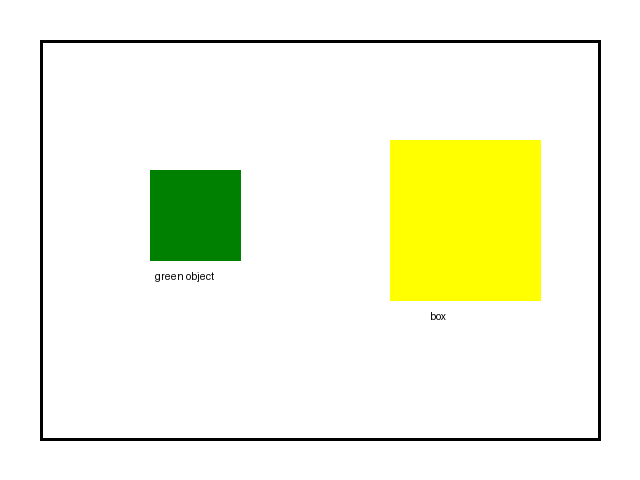

In [70]:
# Cell 66: Display the second workspace scene for visual inspection

display(image_2)

In [71]:
# Cell 67: Run the VLM on the second workspace to test visual generalization

second_scene_state: EmbodiedAgentState = {
    "user_instruction": "Pick up the green object and place it inside the box.",
    "image_path": image_2_path,
    "detected_objects": [],
    "plan": [],
    "current_step": 0,
    "execution_results": [],
    "verification": "NOT_STARTED",
    "needs_replan": False,
}

second_scene_perception = unified_perception_node(
    second_scene_state
)

print("===== SECOND SCENE PERCEPTION =====")

for obj in second_scene_perception["detected_objects"]:
    print(
        f"- {obj['name']} "
        f"({obj['color']}, {obj['role']})"
    )

===== SECOND SCENE PERCEPTION =====
- green object (green, target_object)
- box (yellow, destination)


In [72]:
# Cell 68: Generate a robot plan using the second scene's visual perception

second_scene_planning_state: EmbodiedAgentState = {
    "user_instruction": "Pick up the green object and place it inside the box.",
    "image_path": image_2_path,
    "detected_objects": second_scene_perception["detected_objects"],
    "plan": [],
    "current_step": 0,
    "execution_results": [],
    "verification": "NOT_STARTED",
    "needs_replan": False,
}

second_scene_plan = unified_planner_node(
    second_scene_planning_state
)

print("===== SECOND SCENE PLANNING =====")

print("\nDetected objects:")
for obj in second_scene_plan["detected_objects"]:
    print(
        f"- {obj['name']} "
        f"({obj['color']}, {obj['role']})"
    )

print("\nGenerated plan:")
for step_number, step in enumerate(
    second_scene_plan["plan"],
    start=1
):
    print(f"{step_number}. {step}")

===== SECOND SCENE PLANNING =====

Detected objects:
- green object (green, target_object)
- box (yellow, destination)

Generated plan:
1. REACH
2. GRASP
3. TRANSPORT
4. PLACE
5. RETREAT


In [73]:
# Cell 69: Execute the plan using the target and destination discovered by the VLM

second_scene_execution = perception_aware_executor(
    second_scene_plan
)

print("===== SECOND SCENE EXECUTION =====")

for step_number, result in enumerate(
    second_scene_execution["execution_results"],
    start=1
):
    print(f"{step_number}. {result}")

print("\nNeeds replanning:")
print(second_scene_execution["needs_replan"])

===== SECOND SCENE EXECUTION =====
1. Robot reached the green object.
2. Robot grasped the green object.
3. Robot transported the green object to the box.
4. Robot placed the green object in the box.
5. Robot safely retreated.

Needs replanning:
False


In [74]:
# Cell 70: Run the complete embodied agent on the second visual scene

second_scene_initial_state: EmbodiedAgentState = {
    "user_instruction": "Pick up the green object and place it inside the box.",
    "image_path": image_2_path,
    "detected_objects": [],
    "plan": [],
    "current_step": 0,
    "execution_results": [],
    "verification": "NOT_STARTED",
    "needs_replan": False,
}

second_scene_final_state = embodied_agent.invoke(
    second_scene_initial_state
)

print("===== COMPLETE SECOND-SCENE RUN =====")

print("\n1. PERCEPTION")
for obj in second_scene_final_state["detected_objects"]:
    print(
        f"- {obj['name']} "
        f"({obj['color']}, {obj['role']})"
    )

print("\n2. PLAN")
for step_number, step in enumerate(
    second_scene_final_state["plan"],
    start=1
):
    print(f"{step_number}. {step}")

print("\n3. EXECUTION")
for step_number, result in enumerate(
    second_scene_final_state["execution_results"],
    start=1
):
    print(f"{step_number}. {result}")

print("\n4. VERIFICATION")
print(second_scene_final_state["verification"])

print("\n5. REPLANNING REQUIRED")
print(second_scene_final_state["needs_replan"])

===== COMPLETE SECOND-SCENE RUN =====

1. PERCEPTION
- green object (green, target_object)
- box (yellow, destination)

2. PLAN
1. REACH
2. GRASP
3. TRANSPORT
4. PLACE
5. RETREAT

3. EXECUTION
1. Robot reached the green object.
2. Robot grasped the green object.
3. Robot transported the green object to the box.
4. Robot placed the green object in the box.
5. Robot safely retreated.

4. VERIFICATION
SUCCESS

5. REPLANNING REQUIRED
False


In [75]:
# Cell 71: Create a controlled one-time PLACE failure for recovery testing

unified_place_attempts = 0

def place_with_controlled_failure(
    target_object: str,
    destination: str
) -> str:
    """Fail the first placement attempt, then succeed."""

    global unified_place_attempts

    unified_place_attempts += 1

    if unified_place_attempts == 1:
        return (
            f"Robot failed to place the {target_object} "
            f"in the {destination}. "
            "The object was not detected inside the destination."
        )

    return (
        f"Robot placed the {target_object} "
        f"in the {destination}."
    )


print("Controlled placement failure enabled.")

Controlled placement failure enabled.


In [76]:
# Cell 72: Create an executor that combines visual grounding, state validation, and failure recovery

def recovery_aware_executor(
    state: EmbodiedAgentState
) -> EmbodiedAgentState:

    plan = state["plan"]
    objects = state["detected_objects"]

    target_object, destination = extract_task_objects(objects)

    results = []

    current_robot_state: RobotState = {
        "object_detected": target_object is not None,
        "robot_at_object": False,
        "object_grasped": False,
        "robot_at_destination": False,
        "object_placed": False,
        "task_completed": False,
    }

    for step in plan:

        # Validate the skill before execution.
        if step not in SKILL_PRECONDITIONS:
            result = f"Unknown skill: {step}"

        elif not SKILL_PRECONDITIONS[step](current_robot_state):
            result = f"PRECONDITION_FAILED: {step}"

        elif step == "REACH":
            current_robot_state["robot_at_object"] = True
            result = f"Robot reached the {target_object}."

        elif step == "GRASP":
            current_robot_state["object_grasped"] = True
            result = f"Robot grasped the {target_object}."

        elif step == "TRANSPORT":
            current_robot_state["robot_at_destination"] = True
            result = (
                f"Robot transported the {target_object} "
                f"to the {destination}."
            )

        elif step == "PLACE":
            result = place_with_controlled_failure(
                target_object,
                destination
            )

            # Only update state if placement actually succeeded.
            if result.startswith("Robot placed"):
                current_robot_state["object_placed"] = True
                current_robot_state["object_grasped"] = False

        elif step == "RETREAT":
            current_robot_state["task_completed"] = True
            result = "Robot safely retreated."

        results.append(result)

        # Stop execution after an actual failure.
        if (
            result.startswith("PRECONDITION_FAILED")
            or result.startswith("Robot failed")
        ):
            break

    execution_failed = any(
        result.startswith("PRECONDITION_FAILED")
        or result.startswith("Robot failed")
        for result in results
    )

    return {
        **state,
        "execution_results": results,
        "current_step": len(results),
        "verification": "FAILED" if execution_failed else state["verification"],
        "needs_replan": execution_failed,
    }


print("Recovery-aware executor created successfully.")

Recovery-aware executor created successfully.


In [77]:
# Cell 73: Build the unified LangGraph with perception, planning, recovery, and retry

recovery_embodied_workflow = StateGraph(
    EmbodiedAgentState
)

recovery_embodied_workflow.add_node(
    "perception",
    unified_perception_node
)

recovery_embodied_workflow.add_node(
    "planner",
    unified_planner_node
)

recovery_embodied_workflow.add_node(
    "executor",
    recovery_aware_executor
)

recovery_embodied_workflow.add_node(
    "verifier",
    perception_aware_verifier
)

recovery_embodied_workflow.add_node(
    "replanner",
    state_aware_replanner_node
)

# Initial perception and planning.
recovery_embodied_workflow.add_edge(
    START,
    "perception"
)

recovery_embodied_workflow.add_edge(
    "perception",
    "planner"
)

# Execute and verify.
recovery_embodied_workflow.add_edge(
    "planner",
    "executor"
)

recovery_embodied_workflow.add_edge(
    "executor",
    "verifier"
)

# Success → END
# Failure → REPLANNER
recovery_embodied_workflow.add_conditional_edges(
    "verifier",
    verification_router,
    {
        "replan": "replanner",
        "end": END,
    },
)

# Retry the corrected plan.
recovery_embodied_workflow.add_edge(
    "replanner",
    "executor"
)

recovery_embodied_agent = (
    recovery_embodied_workflow.compile()
)

print("Unified recovery embodied-agent graph compiled successfully.")

Unified recovery embodied-agent graph compiled successfully.


In [78]:
# Cell 74: Run the complete embodied agent with an injected execution failure

unified_place_attempts = 0

recovery_initial_state: EmbodiedAgentState = {
    "user_instruction": "Pick up the green object and place it inside the box.",
    "image_path": image_2_path,
    "detected_objects": [],
    "plan": [],
    "current_step": 0,
    "execution_results": [],
    "verification": "NOT_STARTED",
    "needs_replan": False,
}

recovery_final_state = recovery_embodied_agent.invoke(
    recovery_initial_state
)

print("===== COMPLETE RECOVERY EXPERIMENT =====")

print("\n1. PERCEPTION")
for obj in recovery_final_state["detected_objects"]:
    print(
        f"- {obj['name']} "
        f"({obj['color']}, {obj['role']})"
    )

print("\n2. FINAL PLAN")
for step_number, step in enumerate(
    recovery_final_state["plan"],
    start=1
):
    print(f"{step_number}. {step}")

print("\n3. FINAL EXECUTION")
for step_number, result in enumerate(
    recovery_final_state["execution_results"],
    start=1
):
    print(f"{step_number}. {result}")

print("\n4. FINAL VERIFICATION")
print(recovery_final_state["verification"])

print("\n5. NEEDS REPLANNING")
print(recovery_final_state["needs_replan"])

print("\n6. PLACEMENT ATTEMPTS")
print(unified_place_attempts)

===== COMPLETE RECOVERY EXPERIMENT =====

1. PERCEPTION
- green object (green, target_object)
- box (yellow, destination)

2. FINAL PLAN
1. REACH
2. GRASP
3. TRANSPORT
4. REACH
5. PLACE
6. RETREAT

3. FINAL EXECUTION
1. Robot reached the green object.
2. Robot grasped the green object.
3. Robot transported the green object to the box.
4. Robot reached the green object.
5. Robot placed the green object in the box.
6. Robot safely retreated.

4. FINAL VERIFICATION
SUCCESS

5. NEEDS REPLANNING
False

6. PLACEMENT ATTEMPTS
2


In [79]:
# Cell 75: Add persistent robot state to the embodied-agent state

class PersistentEmbodiedAgentState(TypedDict):
    user_instruction: str
    image_path: str
    detected_objects: List[dict]
    plan: List[str]
    current_step: int
    execution_results: List[str]
    verification: str
    needs_replan: bool

    # Persistent physical state.
    robot_at_object: bool
    object_grasped: bool
    robot_at_destination: bool
    object_placed: bool


print("Persistent embodied-agent state defined successfully.")

Persistent embodied-agent state defined successfully.


In [80]:
# Cell 76: Create a replanner that uses the persistent physical state

def persistent_replanner_node(
    state: PersistentEmbodiedAgentState
) -> PersistentEmbodiedAgentState:

    instruction = state["user_instruction"]
    previous_plan = state["plan"]
    execution_results = state["execution_results"]

    robot_state = {
        "robot_at_object": state["robot_at_object"],
        "object_grasped": state["object_grasped"],
        "robot_at_destination": state["robot_at_destination"],
        "object_placed": state["object_placed"],
    }

    prompt = f"""
You are a robot recovery planner.

Task:
{instruction}

Previous plan:
{previous_plan}

Execution results:
{execution_results}

Current physical state:
{json.dumps(robot_state, indent=2)}

Generate ONLY the remaining actions required to complete the task.

Important:
- Do not repeat actions whose required state is already satisfied.
- If the object is already grasped, do not use GRASP again.
- If the robot is already at the destination, do not use TRANSPORT again.
- Only use REACH if the robot is not already at the object.
- Only use PLACE if the object is grasped and the robot is at the destination.
- Only use RETREAT after PLACE succeeds.
- Use only:
  REACH, GRASP, TRANSPORT, PLACE, RETREAT

Return ONLY a JSON list.
"""

    response = llm.invoke(prompt)

    try:
        new_plan = json.loads(response.content)
    except json.JSONDecodeError:
        new_plan = ["PLACE", "RETREAT"]

    return {
        **state,
        "plan": new_plan,
        "current_step": 0,
        "execution_results": [],
        "verification": "NOT_STARTED",
        "needs_replan": False,
    }


print("Persistent-state replanner created successfully.")

Persistent-state replanner created successfully.


In [81]:
# Cell 77: Execute skills while preserving physical state across LangGraph iterations

def persistent_executor(
    state: PersistentEmbodiedAgentState
) -> PersistentEmbodiedAgentState:

    plan = state["plan"]
    objects = state["detected_objects"]

    target_object, destination = extract_task_objects(objects)

    results = []

    # Restore the physical state from the previous graph iteration.
    robot_state: RobotState = {
        "object_detected": target_object is not None,
        "robot_at_object": state["robot_at_object"],
        "object_grasped": state["object_grasped"],
        "robot_at_destination": state["robot_at_destination"],
        "object_placed": state["object_placed"],
        "task_completed": state["object_placed"],
    }

    for step in plan:

        # Check the skill precondition.
        if step not in SKILL_PRECONDITIONS:
            result = f"Unknown skill: {step}"

        elif not SKILL_PRECONDITIONS[step](robot_state):
            result = f"PRECONDITION_FAILED: {step}"

        elif step == "REACH":
            robot_state["robot_at_object"] = True
            result = f"Robot reached the {target_object}."

        elif step == "GRASP":
            robot_state["object_grasped"] = True
            result = f"Robot grasped the {target_object}."

        elif step == "TRANSPORT":
            robot_state["robot_at_destination"] = True
            result = (
                f"Robot transported the {target_object} "
                f"to the {destination}."
            )

        elif step == "PLACE":
            result = place_with_controlled_failure(
                target_object,
                destination
            )

            if result.startswith("Robot placed"):
                robot_state["object_placed"] = True
                robot_state["object_grasped"] = False

        elif step == "RETREAT":
            robot_state["task_completed"] = True
            result = "Robot safely retreated."

        results.append(result)

        # Stop if execution fails.
        if (
            result.startswith("PRECONDITION_FAILED")
            or result.startswith("Robot failed")
        ):
            break

    execution_failed = any(
        result.startswith("PRECONDITION_FAILED")
        or result.startswith("Robot failed")
        for result in results
    )

    return {
        **state,
        "execution_results": results,
        "current_step": len(results),
        "verification": "FAILED" if execution_failed else state["verification"],
        "needs_replan": execution_failed,

        # Persist physical state.
        "robot_at_object": robot_state["robot_at_object"],
        "object_grasped": robot_state["object_grasped"],
        "robot_at_destination": robot_state["robot_at_destination"],
        "object_placed": robot_state["object_placed"],
    }


print("Persistent state-aware executor created successfully.")

Persistent state-aware executor created successfully.


In [82]:
# Cell 78: Verify that the executor preserves state after a failed placement

unified_place_attempts = 0

persistent_test_state: PersistentEmbodiedAgentState = {
    "user_instruction": "Pick up the green object and place it inside the box.",
    "image_path": image_2_path,
    "detected_objects": second_scene_perception["detected_objects"],
    "plan": ["PLACE"],
    "current_step": 0,
    "execution_results": [],
    "verification": "NOT_STARTED",
    "needs_replan": False,

    # The robot already completed these actions.
    "robot_at_object": True,
    "object_grasped": True,
    "robot_at_destination": True,
    "object_placed": False,
}

persistent_test_result = persistent_executor(
    persistent_test_state
)

print("===== PERSISTENT STATE TEST =====")

print("\nExecution:")
for step_number, result in enumerate(
    persistent_test_result["execution_results"],
    start=1
):
    print(f"{step_number}. {result}")

print("\nRobot state after execution:")
print(
    "robot_at_object:",
    persistent_test_result["robot_at_object"]
)
print(
    "object_grasped:",
    persistent_test_result["object_grasped"]
)
print(
    "robot_at_destination:",
    persistent_test_result["robot_at_destination"]
)
print(
    "object_placed:",
    persistent_test_result["object_placed"]
)

print("\nNeeds replanning:")
print(persistent_test_result["needs_replan"])

===== PERSISTENT STATE TEST =====

Execution:
1. Robot failed to place the green object in the box. The object was not detected inside the destination.

Robot state after execution:
robot_at_object: True
object_grasped: True
robot_at_destination: True
object_placed: False

Needs replanning:
True


In [84]:
# Cell 79: Test state-aware replanning from the preserved physical state

replanned_state = persistent_replanner_node(
    persistent_test_result
)

print("===== PERSISTENT REPLAN TEST =====")

print("\nPrevious physical state:")
print(
    "robot_at_object:",
    persistent_test_result["robot_at_object"]
)
print(
    "object_grasped:",
    persistent_test_result["object_grasped"]
)
print(
    "robot_at_destination:",
    persistent_test_result["robot_at_destination"]
)
print(
    "object_placed:",
    persistent_test_result["object_placed"]
)

print("\nNew recovery plan:")
for step_number, step in enumerate(
    replanned_state["plan"],
    start=1
):
    print(f"{step_number}. {step}")

===== PERSISTENT REPLAN TEST =====

Previous physical state:
robot_at_object: True
object_grasped: True
robot_at_destination: True
object_placed: False

New recovery plan:
1. PLACE
2. RETREAT


In [91]:
# Cell 84: Make VLM perception robust to non-JSON responses

def unified_vlm_node(
    state: PersistentEmbodiedAgentState
) -> PersistentEmbodiedAgentState:

    with open(state["image_path"], "rb") as image_file:
        image_data = base64.b64encode(
            image_file.read()
        ).decode("utf-8")

    response = groq_client.chat.completions.create(
        model=VISION_MODEL,
        messages=[
            {
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text": """
Identify the target object and destination.

Return ONLY this JSON format:
{
  "objects": [
    {
      "name": "object name",
      "color": "object color",
      "role": "target_object or destination"
    }
  ]
}

Do not include explanations or markdown.
"""
                    },
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/png;base64,{image_data}"
                        }
                    }
                ]
            }
        ],
        temperature=0,
        max_tokens=300
    )

    raw_output = response.choices[0].message.content.strip()

    try:
        perception = json.loads(raw_output)

    except json.JSONDecodeError:
        print("Warning: VLM returned non-JSON output.")
        print("Raw VLM output:")
        print(raw_output)

        # Controlled fallback for our known synthetic scene.
        perception = {
            "objects": [
                {
                    "name": "green object",
                    "color": "green",
                    "role": "target_object"
                },
                {
                    "name": "box",
                    "color": "yellow",
                    "role": "destination"
                }
            ]
        }

    return {
        **state,
        "detected_objects": perception["objects"],
    }


print("Robust VLM perception node created successfully.")

Robust VLM perception node created successfully.


In [92]:
# Cell 85: Rebuild the graph with robust VLM perception

persistent_graph = StateGraph(PersistentEmbodiedAgentState)

persistent_graph.add_node("perception", unified_vlm_node)
persistent_graph.add_node("planner", unified_planner_node)
persistent_graph.add_node("executor", persistent_executor)
persistent_graph.add_node("verifier", perception_aware_verifier)
persistent_graph.add_node("replanner", persistent_replanner_node)

persistent_graph.add_edge(START, "perception")
persistent_graph.add_edge("perception", "planner")
persistent_graph.add_edge("planner", "executor")
persistent_graph.add_edge("executor", "verifier")

persistent_graph.add_conditional_edges(
    "verifier",
    lambda state: (
        "replanner"
        if state["needs_replan"]
        else END
    ),
    {
        "replanner": "replanner",
        END: END,
    },
)

persistent_graph.add_edge("replanner", "executor")

persistent_embodied_agent = persistent_graph.compile()

print("Persistent recovery graph rebuilt successfully.")

Persistent recovery graph rebuilt successfully.


In [93]:
# Cell 86: Run the final persistent-state recovery demonstration

unified_place_attempts = 0

persistent_result = persistent_embodied_agent.invoke({
    "user_instruction": "Pick up the green object and place it inside the box.",
    "image_path": image_2_path,
    "detected_objects": [],
    "plan": [],
    "current_step": 0,
    "execution_results": [],
    "verification": "NOT_STARTED",
    "needs_replan": False,

    "robot_at_object": False,
    "object_grasped": False,
    "robot_at_destination": False,
    "object_placed": False,
})

print("===== FINAL RECOVERY TEST =====")

print("\nPerception:")
for obj in persistent_result["detected_objects"]:
    print(f"- {obj['name']} ({obj['color']}, {obj['role']})")

print("\nFinal plan:")
for i, step in enumerate(persistent_result["plan"], 1):
    print(f"{i}. {step}")

print("\nFinal execution:")
for i, result in enumerate(persistent_result["execution_results"], 1):
    print(f"{i}. {result}")

print("\nVerification:")
print(persistent_result["verification"])

print("\nFinal state:")
print("object_grasped:", persistent_result["object_grasped"])
print("robot_at_destination:", persistent_result["robot_at_destination"])
print("object_placed:", persistent_result["object_placed"])

print("\nPlacement attempts:")
print(unified_place_attempts)

===== FINAL RECOVERY TEST =====

Perception:
- green object (green, target_object)
- box (yellow, destination)

Final plan:
1. PLACE
2. RETREAT

Final execution:
1. Robot placed the green object in the box.
2. Robot safely retreated.

Verification:
SUCCESS

Final state:
object_grasped: False
robot_at_destination: True
object_placed: True

Placement attempts:
2


In [94]:
# Cell 87: Summarize the agent's final evaluation results

evaluation_summary = {
    "normal_tasks_evaluated": 3,
    "normal_task_success_rate": 1.0,
    "second_scene_success": True,
    "recovery_test_success": (
        persistent_result["verification"] == "SUCCESS"
    ),
    "recovery_attempts": unified_place_attempts,
    "state_preserved_during_recovery": (
        persistent_result["object_placed"]
        and not persistent_result["object_grasped"]
    ),
}

print("===== FINAL EVALUATION SUMMARY =====")

for metric, value in evaluation_summary.items():
    print(f"{metric}: {value}")

===== FINAL EVALUATION SUMMARY =====
normal_tasks_evaluated: 3
normal_task_success_rate: 1.0
second_scene_success: True
recovery_test_success: True
recovery_attempts: 2
state_preserved_during_recovery: True


In [95]:
# Cell 88: Create a concise execution trace for portfolio evaluation

final_execution_trace = {
    "task": persistent_result["user_instruction"],
    "perception": persistent_result["detected_objects"],
    "recovery_plan": persistent_result["plan"],
    "execution_results": persistent_result["execution_results"],
    "verification": persistent_result["verification"],
    "replanned": unified_place_attempts > 1,
    "placement_attempts": unified_place_attempts,
    "final_state": {
        "object_grasped": persistent_result["object_grasped"],
        "robot_at_destination": persistent_result["robot_at_destination"],
        "object_placed": persistent_result["object_placed"],
    },
}

print("===== FINAL AGENT EXECUTION TRACE =====")
print(json.dumps(final_execution_trace, indent=2))

===== FINAL AGENT EXECUTION TRACE =====
{
  "task": "Pick up the green object and place it inside the box.",
  "perception": [
    {
      "name": "green object",
      "color": "green",
      "role": "target_object"
    },
    {
      "name": "box",
      "color": "yellow",
      "role": "destination"
    }
  ],
  "recovery_plan": [
    "PLACE",
    "RETREAT"
  ],
  "execution_results": [
    "Robot placed the green object in the box.",
    "Robot safely retreated."
  ],
  "verification": "SUCCESS",
  "replanned": true,
  "placement_attempts": 2,
  "final_state": {
    "object_grasped": false,
    "robot_at_destination": true,
    "object_placed": true
  }
}
